# FITML: Assignment 1, Task 2, Seoul Bike Rentals
The aim of this first assignment is to predict the number of bike rentals in Seoul at any given moment.

## Preparations (do not change this part)

### Load libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Load and preprocess data
- Data is stored in a CSV file
- *parse_dates = [0]* indicates that the first column contains the date
- *date_format* can be used to inform the parser about the format
- *rename* can be used to rename columns and rows

**Hint**: Observe how the chaining of methods works in this example.

In [2]:
data = (pd.read_csv("data/SeoulBikeData.csv", parse_dates=[0],
                   date_format = '%d/%m/%Y')
                   .rename(columns = {'Date':'date', 'Rented Bike Count':'count', 'Hour':'hour', 'Temperature(°C)': 'temp',
    'Humidity(%)': 'humidity', 'Wind speed (m/s)': 'wind speed', 'Visibility (10m)':'visibility', 'Dew point temperature(°C)':'dew point',
    'Solar Radiation (MJ/m2)': 'solar radiation', 'Rainfall(mm)': 'rain', 'Snowfall (cm)':'snow', 'Seasons':'season', 'Holiday':'holiday', 'Functioning Day':'workingday'})
)

### Analyze data
The data consists of one row per hour. Columns include the date, the number of rented bikes (count), weather conditions, as well as auxiliary calendar variables (season, holiday, etc).

In [3]:
data.head() # print first 5 rows

,date,count,hour,temp,humidity,wind speed,visibility,dew point,solar radiation,rain,snow,season,holiday,workingday
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [4]:
data.dtypes # print data types

date               datetime64[us]
count                       int64
hour                        int64
temp                      float64
humidity                    int64
wind speed                float64
visibility                  int64
dew point                 float64
solar radiation           float64
rain                      float64
snow                      float64
season                        str
holiday                       str
workingday                    str
dtype: object

In [5]:
data.describe() # get descriptive statistics of the numeric variables

,date,count,hour,temp,humidity,wind speed,visibility,dew point,solar radiation,rain,snow
count,8760,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,2018-06-01 00:00:00,704.602055,11.500000,12.882922,58.226256,1.724909,1436.825799,4.073813,0.569111,0.148687,0.075068
min,2017-12-01 00:00:00,0.000000,0.000000,-17.800000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000
25%,2018-03-02 00:00:00,191.000000,5.750000,3.500000,42.000000,0.900000,940.000000,-4.700000,0.000000,0.000000,0.000000
50%,2018-06-01 00:00:00,504.500000,11.500000,13.700000,57.000000,1.500000,1698.000000,5.100000,0.010000,0.000000,0.000000
75%,2018-08-31 00:00:00,1065.250000,17.250000,22.500000,74.000000,2.300000,2000.000000,14.800000,0.930000,0.000000,0.000000
max,2018-11-30 00:00:00,3556.000000,23.000000,39.400000,98.000000,7.400000,2000.000000,27.200000,3.520000,35.000000,8.800000
std,NaN,644.997468,6.922582,11.944825,20.362413,1.036300,608.298712,13.060369,0.868746,1.128193,0.436746


In [6]:
data.info() # get info and check whether there are any NAs

<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   date             8760 non-null   datetime64[us]
 1   count            8760 non-null   int64         
 2   hour             8760 non-null   int64         
 3   temp             8760 non-null   float64       
 4   humidity         8760 non-null   int64         
 5   wind speed       8760 non-null   float64       
 6   visibility       8760 non-null   int64         
 7   dew point        8760 non-null   float64       
 8   solar radiation  8760 non-null   float64       
 9   rain             8760 non-null   float64       
 10  snow             8760 non-null   float64       
 11  season           8760 non-null   str           
 12  holiday          8760 non-null   str           
 13  workingday       8760 non-null   str           
dtypes: datetime64[us](1), float64(6), int64(4), str(3)


#### Plot some histograms of all numeric variables excluding date and hour
**Hint**: the *drop* method can be used to drop columns but it only overwrites the original dataframe if *inplace = true* is used. Otherwise it returns the transformed df.

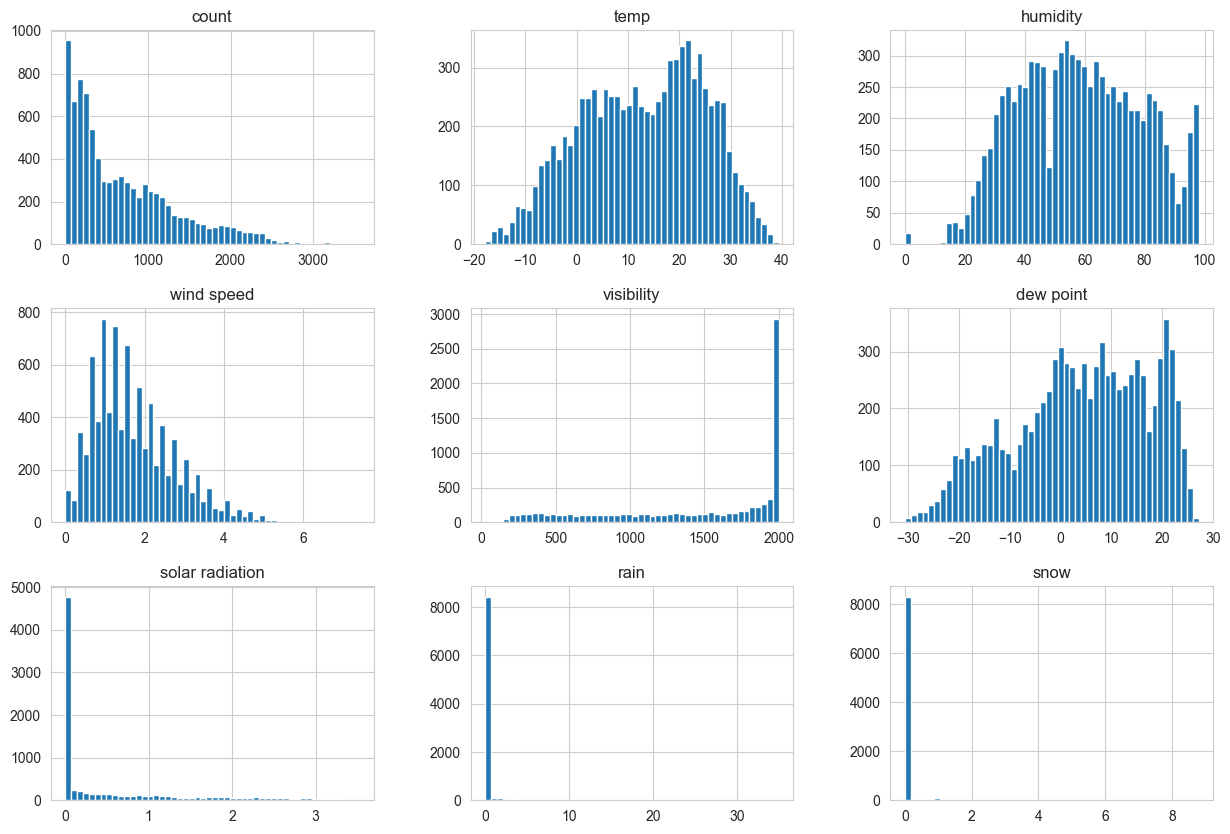

In [7]:
data.drop(["date", "hour"], axis = 1).hist(bins = 50, figsize = (15, 10))
plt.show()

#### Scatterplots of all pairs of numeric variables

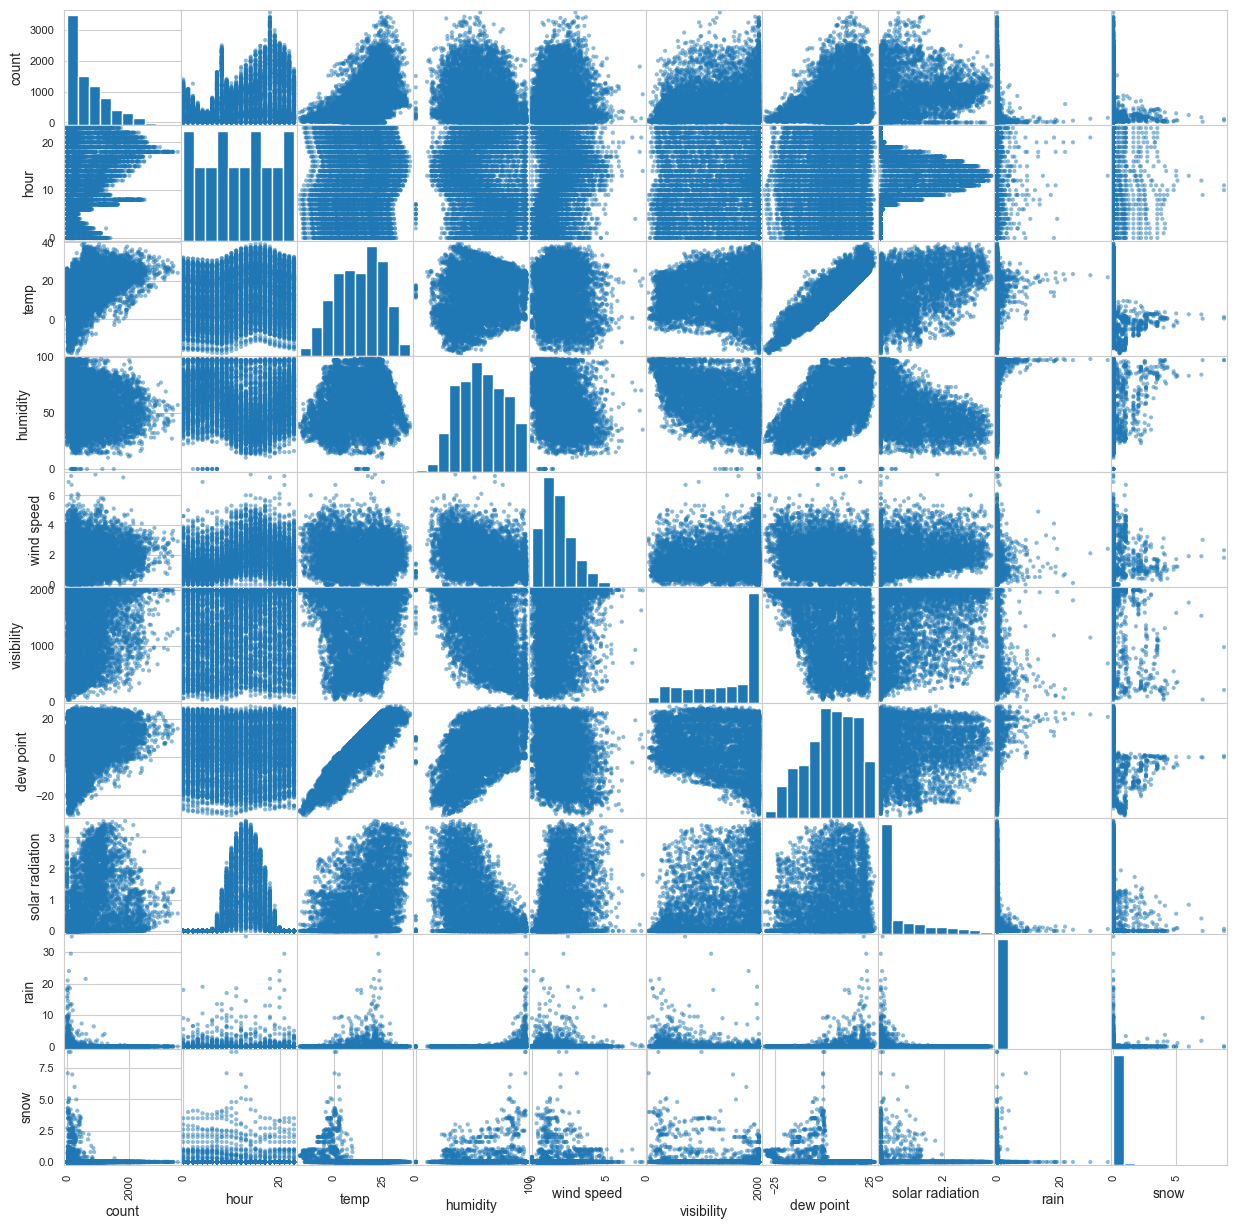

In [8]:
from pandas.plotting import scatter_matrix
scatter_matrix(data.drop(["date"], axis = 1), figsize=(15, 15))
plt.show()

#### Visualize correlations

<Axes: >

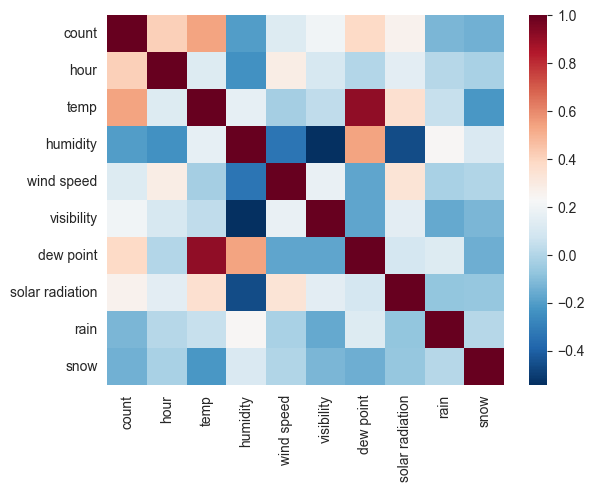

In [9]:
import seaborn as sns
sns.heatmap(data.select_dtypes(include=['number']).corr(),
    xticklabels=data.select_dtypes(include=['number']).columns,
    yticklabels=data.select_dtypes(include=['number']).columns,
    cmap='RdBu_r')

### Set aside a test sample
Since rainfall and snowfall have mostly zeros it would be great to have the same proportion of non-zero entries in the train and test set. For this purpose, we use stratified sampling. However, one can only use one feature to stratify.

In [10]:
print(f"Hours with snowwfall: {len(data[data['snow'] > 0])} ({len(data[data['snow'] > 0]) / data.shape[0] * 100:.2f}%), hours with rain: {len(data[data['rain'] > 0])} ({len(data[data['rain'] > 0]) / data.shape[0] * 100:.2f}%).")

Hours with snowwfall: 443 (5.06%), hours with rain: 528 (6.03%).


In [11]:
num_data = data.select_dtypes(include=['number'])
corr_matrix = num_data.corr()
corr_matrix['snow'].sort_values(ascending=False)

snow               1.000000
humidity           0.108183
rain               0.008500
wind speed        -0.003554
hour              -0.021516
solar radiation   -0.072301
visibility        -0.121695
count             -0.141804
dew point         -0.150887
temp              -0.218405
Name: snow, dtype: float64

In [12]:
corr_matrix['rain'].sort_values(ascending=False)

rain               1.000000
humidity           0.236397
dew point          0.125597
temp               0.050282
hour               0.008715
snow               0.008500
wind speed        -0.019674
solar radiation   -0.074290
count             -0.123074
visibility        -0.167629
Name: rain, dtype: float64

**Decision**: Since snowfall is slightly rarer and has a smaller correlation with other features, we choose the snowfall variable for stratification.

**Reasoning**: Variables with more extreme outliers (e.g., less non-zero values) are less likely to be well represented in a random sample. Features that are less correlated with other features are more likely to have a strong independent effect and should therefore be taken more seriously in stratified sampling.

#### Stratification by clustering
Since the variable snowfall is numeric, classic stratification strategies based on categorical variables fail. In order to convert snowfall into a categorical variable we cluster the feature *snow* into five clusters and use the cluster number as basis for stratification.

In [13]:
from sklearn.cluster import KMeans

# use k-means to cluster snowfall data into 5 clusters
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init = 10).fit(data["snow"].values.reshape(-1, 1))
stratify_clusters = kmeans.labels_
cluster_centers = kmeans.cluster_centers_

# add cluster column to data
data["cluster"] = stratify_clusters

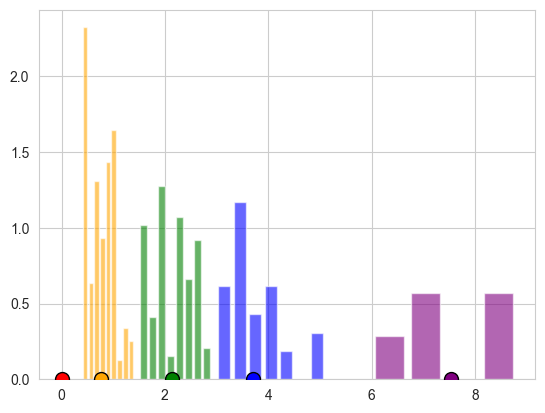

In [14]:
# Plot a histogram of the snowfall and color code the clusters
colors = ['red', 'blue', 'green', 'purple', 'orange']  # Add more colors if needed

x = data["snow"].values
# Plot histograms for each cluster separately
for i in range(1,n_clusters):
    plt.hist(x[stratify_clusters == i], bins='auto', color=colors[i], alpha=0.6, label=f'Cluster {i}', rwidth=0.8, density = True, )

# plot cluster centers
for i, center in enumerate(cluster_centers):
    plt.scatter(center, 0, color=colors[i], s=100, edgecolors='black', zorder=5)  # zorder to place circle above the histogram bars


#### Split the data into training and test sets

In [15]:
from sklearn.model_selection import train_test_split

#training_data, test_data = train_test_split(data, random_state = 42, test_size = 0.2, stratify = stratify_clusters)
training_data, test_data = train_test_split(data, random_state = 42, test_size = 0.2)
training_data_response = training_data[["count"]]
training_data_features = training_data.drop(["count"], axis = 1)
test_data_response = test_data[["count"]]
test_data_features = test_data.drop(["count"], axis = 1)

In [16]:
# save the cluster numbers for the test set for later and drop the cluster numbers from the training and test sets
training_cluster_numbers = training_data_features["cluster"]
training_data_features.drop(["cluster"], axis = 1, inplace = True)
test_data_features.drop(["cluster"], axis = 1, inplace = True)

## Transformations and Feature Engineering
In order to transform our data we will use scikit learn pipelines, which allow to script a well-defined transformations from input data to output data or even to estimated models.

Each step in a pipeline has a fit and a transform method (and possibly also a fit_transform method that first finds the correct parameters of the method and then transforms the data in a single step).

**Hint**: You can change this part as you see fit. Better features might give better (more interpretable) models. The code below is merely a suggestion.

### Add the cumulative snowfall variables to the dataset
Rentals depend on snowfall. However, as opposed to rain, it is plausible that snowfall affects the rentals not only in the time that the snow falls but also in the time afterwards (when the streets are still covered in snow).

In order to add a variable that adds the cumulative snowfall in the recent hours, we define a class of the type BaseEstimator, TransformerMixin.

In [17]:
from sklearn.base import BaseEstimator, TransformerMixin

class SnowFallAdder(BaseEstimator, TransformerMixin):
    def __init__(self, max_lag=6):
        self.max_lag = max_lag

    def fit(self, X, y=None):
        self.original_feature_names_ = X.columns.tolist()
        return self

    def transform(self, X, y=None):
        recent_snow = np.zeros((X.shape[0], self.max_lag))
        for l in range(self.max_lag):
            recent_snow[:, l] = X['snow'].rolling(window=l+1).sum()

        return np.c_[X.values, recent_snow]

    def get_feature_names_out(self, input_features=None):
        # Generate names for the new features
        new_feature_names = [f'cum_snow_{i}' for i in range(self.max_lag)]

        output_feature_names = self.original_feature_names_ + new_feature_names

        return np.array(output_feature_names)

### Define pipeline for numerical attributes
The pipeline consists of a list of transformers that contain tuples with *name*, *name of class* that are applied sequentially to the data.

In our case these are
- Our custom snow transformer
- A standard imputer that replaces NAs by zeros
- A standard scaler that substracts means and divides by the standard deviation of the features

In [18]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

num_pipeline = Pipeline([
    ('snow', SnowFallAdder(max_lag = 10)),
    ('imputer', SimpleImputer(strategy = "constant", fill_value = 0)),
    ('std_scaler', StandardScaler())
])

### Define a pipeline for the categorical variables
We use the following transformers
- A custom transformer that deletes the date column and adds new features *month* and *weekday*.
- A one-hot encoder that transforms all categorical variables to sets of binary variables.

In [19]:
# define custom function to add calendar variables
class CalendarAdder(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        if isinstance(X, pd.DataFrame):
          self.original_feature_names_ = X.columns.tolist()
          self.original_feature_names_.remove("date")
        return self

    def transform(self, X, y=None):
        weekday = X["date"].dt.weekday
        month = X["date"].dt.month

        # drop the date variable
        X = X.drop(["date"], axis=1)
        return np.c_[X, month, weekday]

    def get_feature_names_out(self, input_features=None):
        # Generate names for the new features
        new_feature_names = ['month', 'weekday']

        # Combine the original feature names with the new feature names
        if input_features is None:
            output_feature_names = self.original_feature_names_ + new_feature_names
        else:
            input_features = input_features.tolist()
            input_features.remove("date")
            output_feature_names =  input_features + new_feature_names

        return np.array(output_feature_names)

In [20]:
from sklearn.preprocessing import OneHotEncoder
# define pipeline for categorical features
cat_pipeline = Pipeline([
    ('calendar', CalendarAdder()),
    ('cat', OneHotEncoder())
])

### Define the full pipeline by concatenating the two pipelines above
**Note**: In the *ColumnTransformer* we use a third element in the tuples that indicate which rows to pass to the respective pipelines.

**Note**: Pipelines are also transformers and can therefore be nested.

In [21]:
from sklearn.compose import ColumnTransformer

# define full pipeline
num_attribs = training_data_features.select_dtypes(include=['number']).columns.tolist()
cat_attribs = [item for item in training_data_features.columns.tolist() if item not in num_attribs]

full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", cat_pipeline, cat_attribs),
])

training_data_features_augmented = full_pipeline.fit_transform(training_data_features)
test_data_features_augmented = full_pipeline.transform(test_data_features)

In [22]:
# reassemble data frame
feature_names = [s.replace('num__', '').replace('cat__', '') for s in full_pipeline.get_feature_names_out().tolist()]
X_train = pd.DataFrame(training_data_features_augmented, columns = feature_names)
X_test = pd.DataFrame(test_data_features_augmented, columns = feature_names)
y_train = training_data_response["count"]
y_test = test_data_response["count"]

## Blackbox Models to the Data

Below we train a random forest estimator, XGBoost, and LightGBM as blackbox models for our problem.

**Note**: Hyperparameter tuning might take a while (especially when run online in Google Colab)

In [23]:
fits = pd.DataFrame(columns = ["RMSE", "MAE", "R2"])

### Random Forest Model

In [33]:
# do grid search for the random forest model
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import StratifiedKFold

stratified_kfold = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)
forest_reg = RandomForestRegressor()
#
# param_grid = [
#     {'n_estimators': [50, 75, 100, 125, 150], 'max_features': [20, 25, 30, 35, 40, 45]},
#     {'bootstrap': [False], 'n_estimators': [50, 75, 100, 125, 150], 'max_features': [20, 25, 30, 35, 40, 45]},
# ]
# grid_search = GridSearchCV(forest_reg, param_grid, cv=stratified_kfold.split(training_data_features_augmented, training_cluster_numbers),
#                            scoring='neg_mean_squared_error', return_train_score=True, n_jobs = 10)
# grid_search.fit(X_train, y_train)

**Alternative**: Simply fit the model with the parameters found above

*bootstrap* = False

*max_features* = 25

*n_estimators* = 100

In [25]:
rf = RandomForestRegressor(n_estimators=100, max_features=25, bootstrap=False, random_state=42)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",25
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples

In [26]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# predict outcomes for test data and check standard deviation
rf_predict = rf.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predict)).round(2)
rf_mae = mean_absolute_error(y_test, rf_predict)
rf_r2 = r2_score(y_test, rf_predict)

fits.loc["Random Forest"] = [rf_rmse, rf_mae, rf_r2]
fits

,RMSE,MAE,R2
Random Forest,181.68,104.110993,0.92078


### XGBoost

In [27]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
#
# # Define the XGBoost model
# xgb_reg = XGBRegressor(objective='reg:squarederror', random_state=42)
#
# # Define the parameter grid for hyperparameter tuning
# param_grid_xgb = {
#     'n_estimators': [100, 150, 200, 250, 300],
#     'max_depth': [7, 9, 11, 13, 15],
#     'learning_rate': [0.01, 0.05, 0.1, 0.2],
#     'subsample': [0.6, 0.8, 1.0],
# }
#
# # Perform grid search with cross-validation
# grid_search_xgb = GridSearchCV(
#     xgb_reg,
#     param_grid_xgb,
#     cv=stratified_kfold.split(training_data_features_augmented, training_cluster_numbers),
#     scoring='neg_mean_squared_error',
#     return_train_score=True,
#     n_jobs=10
# )
#
# # Fit the model to the training data
# grid_search_xgb.fit(X_train, y_train)
#
# # Print the best parameters and the best score
# print("Best parameters:", grid_search_xgb.best_params_)
# print("Best RMSE:", np.sqrt(-grid_search_xgb.best_score_).round(2))

**Alternative**: Simply fit the model with the parameters found above

*learning_rate* = 0.05

*max_depth* = 9

*n_estimators* = 300

*subsample* = 0.6

In [28]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
xgb = XGBRegressor(objective='reg:squarederror', learning_rate=0.05, max_depth=9, n_estimators=300, subsample=0.6, random_state=42)
xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [29]:
# predict outcomes for test data and check standard deviation
xgb_predict = xgb.predict(X_test)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_predict)).round(2)
xgb_mae = mean_absolute_error(y_test, xgb_predict)
xgb_r2 = r2_score(y_test, xgb_predict)

fits.loc["XGBoost"] = [xgb_rmse, xgb_mae, xgb_r2]
fits.style.background_gradient(cmap='viridis')

,RMSE,MAE,R2
Random Forest,181.680000,104.110993,0.920780
XGBoost,154.220000,86.407143,0.942913


# Analyze Explainability and Interpretability

## Task 2: Find a Better/Equally Good Intrinsically Interpretable Model
Try out some white-box and glass-box models for the problems. Aim for a comparable quality as the rf model. Quality can be influenced by selection of an appropriate model, feature engineering and a better understanding of the problem.

Possible model classes to explore are

1. Linear regression
2. Support vector machines
3. Rule-based techniques such as RuleFit or CORELS (see the imodels package)
4. Explainable Boosting Machine

You are encouraged to use the techniques discussed in the course but it is highly welcome if you explore related methods and play with the parameters and settings in a way that transcends what was discussed in the lecture.

When fitting models, try to tune the relevant parameters of the method using cross-validation. For this is advisable to run the code locally (not on Google Colab) and use the option *njobs=-1* to make use of parallel processing.

Summarize your findings textually and graphically in this notebook.

### Task 2 Linear regression and Support vector machines

Estimated regression coefficients:
               feature  coefficient
25       workingday_No  -487.680848
26      workingday_Yes   487.680848
32             month_6   304.719319
34             month_8  -280.965241
1                 temp   267.190657
2             humidity  -191.593841
0                 hour   189.942960
5            dew point   119.030691
19       season_Autumn   117.470207
36            month_10   113.197095
31             month_5   110.726062
22       season_Winter   -96.492505
45           weekday_6   -87.466201
28             month_2   -82.508714
6      solar radiation   -79.906832
29             month_3   -77.327073
24  holiday_No Holiday    70.768677
23     holiday_Holiday   -70.768677
33             month_7   -69.654210
7                 rain   -67.274564
21       season_Summer   -45.900131
16          cum_snow_7    42.084988
27             month_1   -41.463398
43           weekday_4    40.735533
41           weekday_2    38.597276
4           visibility    36.

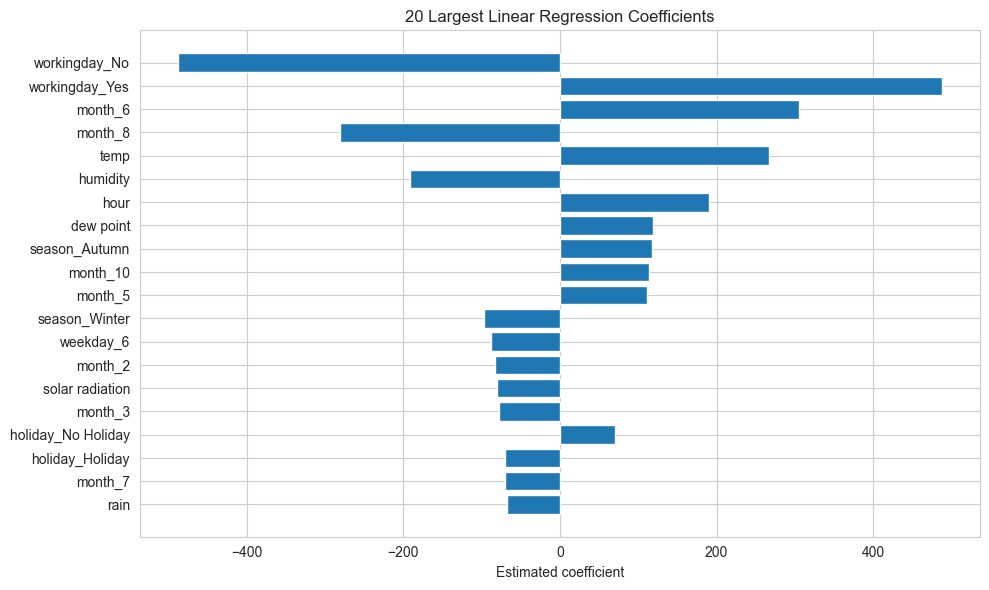

,RMSE,MAE,R2
Linear Regression,419.600000,316.320000,0.577000


In [30]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ordinary Least Squares regression

ols_model = LinearRegression()
ols_model.fit(X_train, y_train)

y_pred_ols = ols_model.predict(X_test)

coef_table = (
    pd.DataFrame({
        "feature": feature_names,
        "coefficient": ols_model.coef_.ravel()
    })
    .assign(abs_coefficient=lambda d: d["coefficient"].abs())
    .sort_values("abs_coefficient", ascending=False)
    .drop(columns="abs_coefficient")
)

print("Estimated regression coefficients:")
print(coef_table)

top_coef = (
    coef_table.reindex(coef_table["coefficient"].abs().sort_values().index)
    .tail(20)
)

plt.figure(figsize=(10, 6))
plt.barh(top_coef["feature"], top_coef["coefficient"])
plt.xlabel("Estimated coefficient")
plt.title("20 Largest Linear Regression Coefficients")
plt.tight_layout()
plt.show()

rmse_ols = np.sqrt(mean_squared_error(y_test, y_pred_ols))
mae_ols = mean_absolute_error(y_test, y_pred_ols)
r2_ols = r2_score(y_test, y_pred_ols)

results = pd.DataFrame(columns=["RMSE", "MAE", "R2"])
results.loc["Linear Regression"] = [
    round(rmse_ols, 2),
    round(mae_ols, 2),
    round(r2_ols, 3)
]

display(results.style.background_gradient(cmap="viridis", axis=0))

Workingday_Yes has coefficient 487.68 meaning rentals increase significantly on working days.
Month 6 which is June has coefficient 304.72 meaning that there is higher rental activity that month.
This drops in month 8 (august) which has coefficient -280.97.
Temperature has coefficient 267.19 meaning warmer weather increases the rental activity.
Humidity has coefficient -191.59 meaning that when it gets more humid there will be fewer rentals.
Hour has coefficient 189.94 and thus the rentals increase throughout the day.


Fitting 5 folds for each of 16 candidates, totalling 80 fits
Optimal parameter values:
{'C': 100, 'epsilon': 0.1, 'kernel': 'linear'}

Estimated SVR coefficients:
               feature  coefficient
26      workingday_Yes   453.566700
25       workingday_No  -453.566700
5            dew point   338.873085
32             month_6   255.510115
2             humidity  -251.748434
34             month_8  -246.082994
0                 hour   136.098062
36            month_10   122.191248
19       season_Autumn   115.205222
31             month_5    89.059555
22       season_Winter   -79.226848
33             month_7   -75.768599
7                 rain   -69.038334
28             month_2   -68.780222
29             month_3   -67.316366
21       season_Summer   -66.341479
45           weekday_6   -52.164279
24  holiday_No Holiday    48.159113
23     holiday_Holiday   -48.159113
1                 temp    44.416031
43           weekday_4    41.751101
6      solar radiation   -41.567425
35       

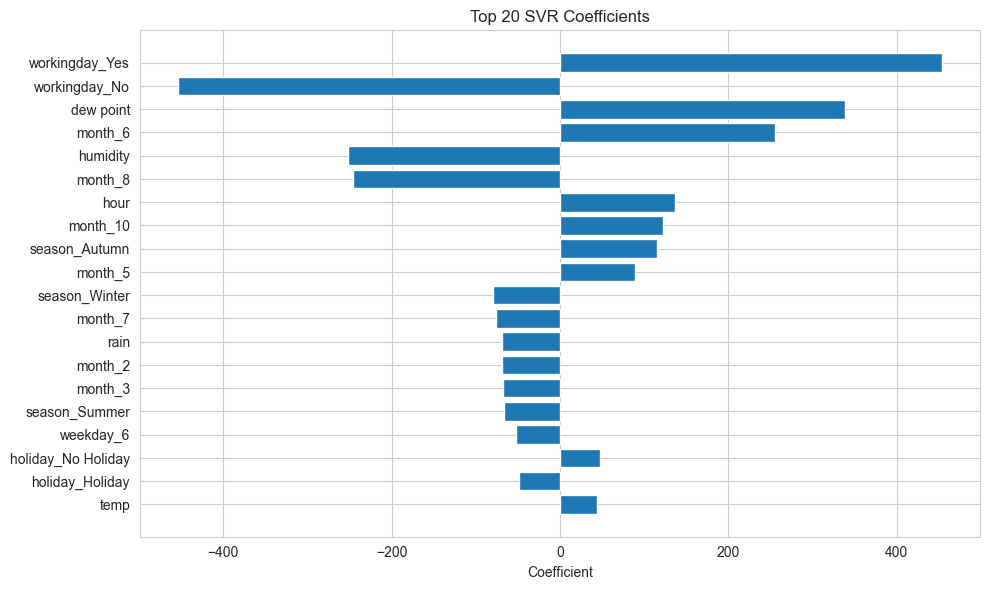

,RMSE,MAE,R2
Linear Regression,419.600000,316.320000,0.577000
SVR,433.330000,305.470000,0.549000


In [31]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Support Vector Regression with cross-validation

svr_model = SVR()

svr_grid = {
    "C": [0.1, 1, 10, 100],
    "epsilon": [0.01, 0.1, 0.5, 1],
    "kernel": ["linear"]
}

svr_search = GridSearchCV(
    estimator=svr_model,
    param_grid=svr_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

svr_search.fit(X_train, y_train.to_numpy())

svr_best = svr_search.best_estimator_

print("Optimal parameter values:")
print(svr_search.best_params_)

# Collect coefficients in a table
svr_coef_table = (
    pd.DataFrame({
        "feature": X_train.columns,
        "coefficient": svr_best.coef_.ravel()
    })
    .assign(abs_coefficient=lambda d: d["coefficient"].abs())
    .sort_values("abs_coefficient", ascending=False)
)

print("\nEstimated SVR coefficients:")
print(svr_coef_table[["feature", "coefficient"]])

# Plot 20 largest coefficients by absolute size
top_svr = (
    svr_coef_table
    .sort_values("abs_coefficient")
    .tail(20)
)

plt.figure(figsize=(10, 6))
plt.barh(top_svr["feature"], top_svr["coefficient"])
plt.xlabel("Coefficient")
plt.title("Top 20 SVR Coefficients")
plt.tight_layout()
plt.show()

# Predictions and evaluation
y_pred_svr = svr_best.predict(X_test)

rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))
mae_svr = mean_absolute_error(y_test, y_pred_svr)
r2_svr = r2_score(y_test, y_pred_svr)

results.loc["SVR"] = [
    round(rmse_svr, 2),
    round(mae_svr, 2),
    round(r2_svr, 3)
]

display(results.style.background_gradient(cmap="viridis", axis=0))

Workingday_Yes has coefficient 453.57 meaning that rentals increase significantly on working days, just like linear regression. Here dew point has a coefficient of 338.87. A high dew point increases the rentals with a stronger effect than the linear regression model. Similar to linear regression June (255.51) has a positive effect and August (-246.08) a negative effect. Humidity (-251.75) has a stronger negative effect on rentals than linear regression. Hour (136.10) means that rentals still increase throughout the day but not as strongly as in linear regression. Interestingly, temperature has a coeffiencient of 44.02 which is significantly lower than in linear regression.

In [35]:
from interpret.glassbox import ExplainableBoostingRegressor
from sklearn.model_selection import GridSearchCV
import numpy as np
import pandas as pd

ebm = ExplainableBoostingRegressor(random_state=42)
param_grid_ebm = {'max_bins':[128, 256], 'max_interaction_bins': [16, 32], 'interactions': [5, 10, 15], 'learning_rate':[0.01, 0.03, 0.05]}

grid_search_ebm = GridSearchCV(ebm, param_grid_ebm, cv=stratified_kfold.split(X_train, training_cluster_numbers), scoring='neg_mean_squared_error', return_train_score=True, n_jobs=-1)
grid_search_ebm.fit(X_train, y_train)

print("Best parameters:", grid_search_ebm.best_params_)
print("Best RMSE:", np.sqrt(-grid_search_ebm.best_score_).round(2))

Best parameters: {'interactions': 15, 'learning_rate': 0.01, 'max_bins': 256, 'max_interaction_bins': 32}
Best RMSE: 240.75

## Task 2 RuleFit and EBM

### RuleFit

1. RuleFit builds an interpretable linear model, with features:
- Linear terms for each feature (standardized)
- Rule featurs: binary indicators are extracted from every internal node of the tree ensemble.

2. We have tuned the following parameters via cross-validation (StratifiedKFold, 4 folds):
- `max_rules` in {200, 400, 600}
- `tree_size` in {3, 4, 5}
- `memory_par` in {0.01, 0.03}

Due to the heavy computational budget, we limited the grid to these three hyperparameters. The grid explores the trade-off between model complexity (more rules / deeper trees) and regularization strength (`memory_par`). Other parameters such as `n_estimators` were left at their defaults, though expanding the grid, with the current parameters and to include other parameters, we could've potentially improve performance.



In [37]:
from imodels import RuleFitRegressor

rulefit = RuleFitRegressor(random_state=42, include_linear=True)
param_grid_rulefit = {
    'max_rules': [200,400,600],
    'tree_size': [3,4,5],
    'memory_par': [0.01, 0.03],
}


grid_search_rulefit = GridSearchCV(rulefit, param_grid_rulefit,
                                   cv=stratified_kfold.split(X_train, training_cluster_numbers),
                                   scoring='neg_mean_squared_error', return_train_score=True, n_jobs=-1)

grid_search_rulefit.fit(X_train, y_train)

print("Best parameters:", grid_search_rulefit.best_params_)
print("Best RMSE:", np.sqrt(-grid_search_rulefit.best_score_).round(2))

**Cross-validation output**:
- Best parameters: {'max_rules': 200, 'memory_par': 0.03, 'tree_size': 5} .
- Best RMSE: 225.0

*Note: the CV RMSE above is the in-sample cross-validated score. The true test-set performance is reported below.*

In [673]:
rulefit = RuleFitRegressor(max_rules=200, tree_size=5, memory_par=0.03, include_linear=True, random_state=42)
rulefit.fit(X_train, y_train)

,n_estimators,100
,tree_size,5
,sample_fract,'default'
,max_rules,200
,memory_par,0.03
,tree_generator,None
,lin_trim_quantile,0.025
,lin_standardise,True
,exp_rand_tree_size,True
,include_linear,True
,alpha,None


In [675]:
rulefit_predict = rulefit.predict(X_test)
rulefit_rmse = np.sqrt(mean_squared_error(y_test, rulefit_predict))
rulefit_mae = mean_absolute_error(y_test, rulefit_predict)
rulefit_r2 = r2_score(y_test, rulefit_predict)

fits.loc["RuleFit"] = [rulefit_rmse, rulefit_mae, rulefit_r2]
fits.style.background_gradient(cmap='viridis')

,RMSE,MAE,R2
Random Forest,181.680000,104.110993,0.920780
XGBoost,154.220000,86.407143,0.942913
RuleFit,224.127528,151.649569,0.879435
EBM,244.009881,165.176981,0.857095


#### RuleFit Performance Summary

**Performance gap discussion:**
RuleFit's R² of 0.88 falls  below the the other R². This gap is expected for several reasons:

1. **Linear aggregation constraint**: RuleFit combines rules and linear terms via Lasso-penalized linear regression. This limits its ability to capture the complex non-linear interactions that tree ensembles model naturally.

2. **Rule discretization**: Converting continuous relationships into binary rule indicators loses information.

3. **Regularization trade-off**: The Lasso penalty enforces sparsity for interpretability.

Despite the gap, RuleFit offers a key advantage: every prediction can be decomposed into a transparent sum of interpretable terms. The feature importance, rule tables, and PDPs later on demonstrate this interpretability.

#### Predicted vs. Actual Plot
A scatter of predicted vs. actual values reveals where RuleFit struggles. Points far from the diagonal indicate systematic errors.

1. **Low-demand** (0–500 rentals): The model performs well. As predictions cluster tightly around the diagonal.
2. **Mid demand** (500–1500 rentals): Prediction spread increases noticeably. RuleFit tends to both over- and underpredict in this range, reflecting the difficulty of modelling mid-level of demand hours.
3. **High-demand** (>1500 rentals): A clear underprediction pattern emerges, the points consistently falls below the diagonal.

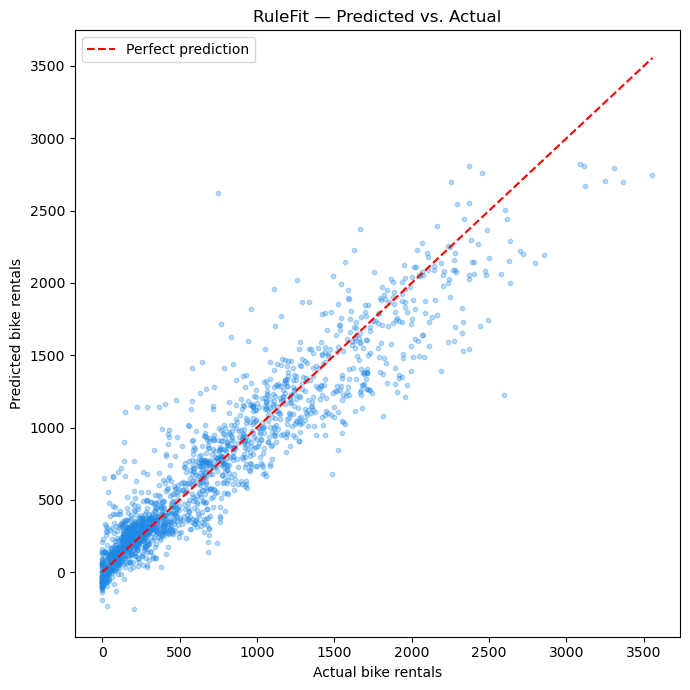

In [718]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_test, rulefit_predict, alpha=0.3, s=10, color='#1E88E5')
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('Actual bike rentals')
ax.set_ylabel('Predicted bike rentals')
ax.set_title('RuleFit — Predicted vs. Actual')
ax.legend()
plt.tight_layout()
plt.show()

#### Residual Analysis
The residual plots reveal systematic patterns in the model's errors.

**Left panel — Residuals vs. Predicted:**
1. The residuals are approximately centered around zero for low predictions, but show a positive skew at higher predicted values. This means that when RuleFit predicts high demand, actual demand tends to be even higher. This aligns with the underprediction at peak hours observed in the predicted vs. actual plot.

**Right panel — Residuals vs. Hour:**
1. Residuals are tightly clustered near zero during nighttime and early morning hours, confirming the model handles low-demand periods well.
2. At specific standardized hour values (~8h and ~17–18h), large positive residual spikes appear. These correspond to the morning and evening commute peaks, where actual demand surges above what the rules predict.


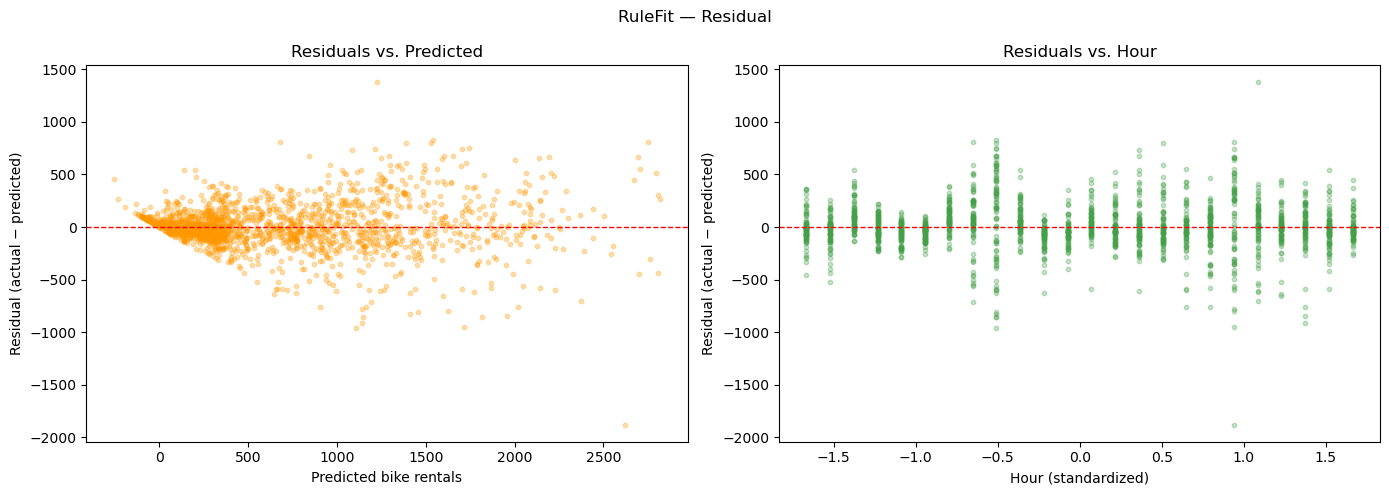

In [815]:
residuals = y_test.values - rulefit_predict

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs predicted
axes[0].scatter(rulefit_predict, residuals, alpha=0.3, s=10, color='#FF9800')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Predicted bike rentals')
axes[0].set_ylabel('Residual (actual − predicted)')
axes[0].set_title('Residuals vs. Predicted')

# Residuals vs hour (key feature)
hour_orig = X_test['hour'].values
axes[1].scatter(hour_orig, residuals, alpha=0.3, s=10, color='#43A047')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('Hour (standardized)')
axes[1].set_ylabel('Residual (actual − predicted)')
axes[1].set_title('Residuals vs. Hour')

plt.suptitle('RuleFit — Residual', fontsize=12)
plt.tight_layout()
plt.show()

#### Feature Importance
1. The RuleFit feature importance bar chart below aggregates two distinct sources of predictive signal for each feature:
   - Direct linear contribution (|coefficient| × feature std)
   - Rule contribution: summed across all decision rules in which the feature appears

2. The results show the following:
   - **hour** is the dominant feature by a large margin, reflecting the strong commute-driven demand pattern.
   - **temp** is also highly important, consistent with warmer weather encouraging cycling.
   - **humidity** and **rain** score high, indicating that adverse weather conditions substantially reduce demand.
   - **solar radiation** adds further weather signal beyond temperature alone.
   - Categorical features such as **workingday_Yes/No** appear prominently, showing that the working-day vs. non-working-day distinction shapes the demand pattern.

3. Aggregating both linear and rule contributions avoids underestimating features that exert influence primarily through interactions within rules.

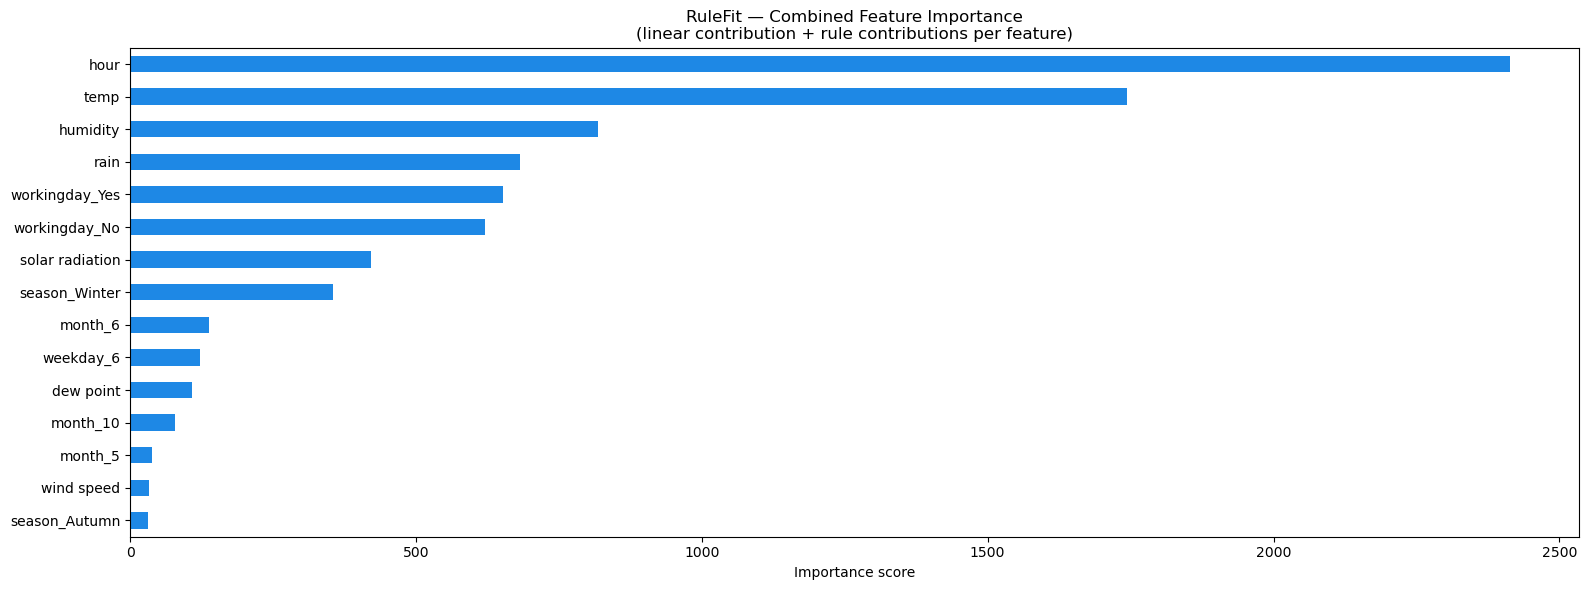

Top 15 features by RuleFit importance:
hour               2414.1184
temp               1743.4525
humidity            818.7730
rain                682.2202
workingday_Yes      653.1281
workingday_No       619.9493
solar radiation     421.3794
season_Winter       355.0275
month_6             138.1113
weekday_6           122.8963
dew point           108.6022
month_10             78.5180
month_5              37.8902
wind speed           33.0125
season_Autumn        30.6174


In [840]:
n_features_rulefit = X_train.shape[1]
importances_rulefit = pd.Series(0.0, index=X_train.columns)

for i, f in enumerate(X_train.columns):
    importances_rulefit[f] += np.abs(rulefit.coef[i]) * X_train[f].std()

for j, rule in enumerate(rulefit.rules_):
    coef = rulefit.coef[n_features_rulefit + j]
    if coef == 0:
        continue
    imp = np.abs(coef) * np.sqrt(rule.support * (1 - rule.support))
    for feat, *_ in rule.agg_dict:
        if feat in importances_rulefit.index:
            importances_rulefit[feat] += imp

importances_rulefit = importances_rulefit.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(16, 6))
importances_rulefit.head(15).plot(kind='barh', ax=ax, color='#1E88E5')
ax.invert_yaxis()
ax.set_title('RuleFit — Combined Feature Importance\n'
             '(linear contribution + rule contributions per feature)')
ax.set_xlabel('Importance score')
plt.tight_layout()
plt.show()

print('Top 15 features by RuleFit importance:')
print(importances_rulefit.head(15).round(4).to_string())


#### Rules
1. In the following section, we take a closer look at the interaction of rules.
2. At first we take a look at the top 15 rules sorted by importance, we highlight some of the most important rules below.

##### Note: Features are standardised in the pipeline part of this notebook. Here we calculated back the standardized features.
- **Rule 86** (`hour > ~11h`): The most important rule, with a large negative coefficient. It sets a lower baseline for the second half of the day, which is then overridden by more specific positive rules during peak windows (e.g., evening commute).
- **Rule 159** (`hour ~7–11h, dry, temp > ~3°C, not Saturday, working day`): Captures the weekday morning commute spike. Low support (3.8%) but an extremely large positive coefficient (+357.4), identifying dry, non-freezing weekday mornings as the highest-demand windows.
- **Rule 93** (`hour > ~8h, rain < ~0.5mm, working day`): Broadly applicable (60.9% of obs.), providing a general demand lift across dry working-day hours.
- **Rule 22** (`hour ~7–11h, dry, temp > ~3°C, Saturday`): The weekday/weekend mirror of Rule 159, with a large negative coefficient (−348.9). This corrects the prediction downward for Saturday mornings, which lack the commuter spike despite otherwise similar conditions.
- **Rule 132** (`hour > ~7h, temp ~10–25°C, humidity < ~75%, not winter, working day`): A seasonal refinement (coef = +131.6, 20.6% of obs.), boosting demand when comfortable cycling conditions align with a working day. 

- The pattern confirms that RuleFit decomposes demand into broad negative baselines offset by specific positive rules, recovering high demand only when time, weather, and day-type align correctly.

 
4. To improve direct readibility, we have made a bar chart which clearly visualizes these findings:
##### Note: red = decrease in rentals, blue = increase in rentals
- The tallest red bar (rule 86) stands alone as broad hour suppressor
- Cluster of high-importance blue bars mostly cover working-day , "good" weather and correct hour combinations.
- The lower ranked red bars represent additional suppressing rules for off-peak conditions.
- This pattern confirms that RuleFit decomposes demand into broad negative baselines offset by specific positive rules
  - recovering high demand only when time, weather, and day-type align correctly

In [713]:
rule_records = []
for j, rule in enumerate(rulefit.rules_):
    coef = rulefit.coef[n_features_rulefit + j]
    if coef == 0:
        continue
    imp = np.abs(coef) * np.sqrt(rule.support * (1 - rule.support))
    rule_records.append({
        'rule':      str(rule),
        'coef':      round(float(coef), 3),
        'support':   round(float(rule.support), 3),
        'importance': round(float(imp), 4)
    })

rules_df = pd.DataFrame(rule_records).sort_values('importance', ascending=False)
rules_df.head(15)

,rule,coef,support,importance
86,hour > -0.43598,-161.639,0.628,78.1263
159,hour <= -0.43598 and hour > -0.72564 and rain <= 0.05341 and temp > -0.74722 and weekday_6 <= 0.5 and workingday_No <= 0.5,357.370,0.038,68.5364
93,hour > -0.58081 and rain <= -0.08716 and workingday_Yes > 0.5,124.087,0.609,60.5588
132,hour > -0.72564 and humidity <= 1.09093 and season_Winter <= 0.5 and temp <= 1.32185 and temp > 0.28731 and workingday_Yes > 0.5,131.609,0.206,53.2178
162,hour <= 1.01233 and hour > 0.8675 and humidity <= 1.48228 and temp > -0.81871,295.451,0.031,51.5197
130,hour <= 1.59165 and hour > 0.72267 and rain <= -0.08716 and temp <= 1.63725 and temp > -0.53695 and workingday_Yes > 0.5,125.298,0.145,44.1147
137,hour <= 1.59165 and hour > 0.72267 and humidity <= 1.38444 and season_Winter <= 0.5 and workingday_Yes > 0.5,111.886,0.166,41.5971
142,hour > -0.72564 and humidity <= 1.58012 and month_10 > 0.5 and season_Winter <= 0.5 and workingday_No <= 0.5,175.347,0.055,39.9542
31,hour <= 0.72267 and solar radiation <= -0.65345,-74.909,0.310,34.6561
103,hour <= -1.4498 and rain <= 0.05341 and solar radiation <= -0.65345 and temp > -0.11641 and workingday_No <= 0.5,179.387,0.037,33.9056


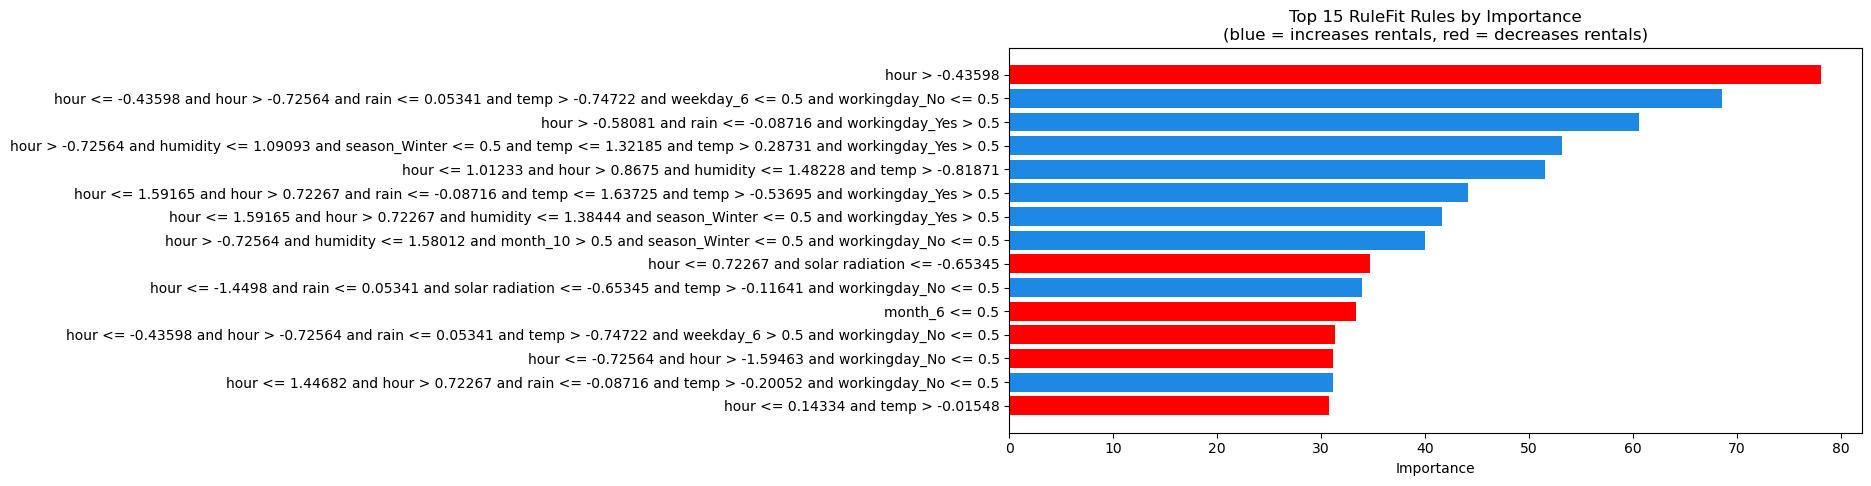

In [681]:
# Bar chart of the top 10 rules, colour-coded by effect direction
top15 = rules_df.head(15)
rule_colors = ['red' if c < 0 else '#1E88E5' for c in top15['coef']]

fig, ax = plt.subplots(figsize=(11, 5))
ax.barh(top15['rule'], top15['importance'], color=rule_colors)
ax.invert_yaxis()
ax.set_title('Top 15 RuleFit Rules by Importance\n(blue = increases rentals, red = decreases rentals)')
ax.set_xlabel('Importance')
plt.show()

#### High-Support Rules
1. Below we filter for rules with support > 40%, i.e., rules that apply to the largest share of observations. These broadly active conditions shape the model's baseline predictions.

2. Key high-support rules:
   - `workingday_Yes > 0.5`: A small positive boost (+1.6) applying to nearly every working-day observation. Reflecting that working days see more rentals as a baseline
   - `month_6 <= 0.5`: A large negative push applying to every month except June, confirming June as the peak demand month.
   - `Temp <= 17°C` Below average temperatures suppress demand for the majority of the year, since most of Seoul's calendar falls below this.
   - `hour > ~11h`: The broad daytime baseline rule from the top-15 analysis reappears here.
   - `hour > ~8h, no rain, working day`: The main positive counterpart, pushing predictions upward for dry working-day hours.

3. These high-support rules reinforce the feature importance findings: **hour**, **temp**, and **workingday** are the dominant drivers.
   - The importance plot showed "hour" and "temp" as the two most important features by a large margin, and the high-support rules confirm this, the most widely active rules in the model are built around hour thresholds and temperature conditions. 

In [730]:
rules_list = rulefit.rules_
coefs      = rulefit.coef[n_features_rulefit:]

# Dataframe of active rules with support > 40%
rule_records = []
for rule, coef in zip(rules_list, coefs):
    if coef != 0 and rule.support > 0.40:
        rule_records.append({
            'rule':    str(rule),
            'coef':    round(float(coef), 6),
            'support': round(float(rule.support), 6),
        })

rules_display = (pd.DataFrame(rule_records).set_index('rule').sort_values('support', ascending=False))
rules_display.style.background_gradient(cmap='viridis', subset=['coef', 'support'])

,coef,support
rule,,
workingday_Yes > 0.5,1.632662,0.966182
month_6 <= 0.5,-121.859722,0.918236
hour <= 0.72267,-0.143189,0.710046
temp <= 0.69103,-0.154145,0.706764
rain <= -0.08716 and temp > -0.8818 and workingday_No <= 0.5,65.140137,0.688784
temp > -0.54536,-1.408232,0.679795
temp <= 0.54805,-50.530739,0.651113
hour > -0.43598,-161.638579,0.627997
hour <= 0.43301,-3.429058,0.625285


#### RuleFit Partial Dependence Plots

The PDP plots complement the rules by showing the continuous marginal effect of each feature. 
##### Note: x-axes show standardized values; approximate original values are used in this text.

- **Hour**: Confirms the commuter patterns suggested by rule 86 & 159. A morning spike (~ 8h) and a sharp evening peak (~ 18h) become now visible
- **Temp**: Shows a monotonic rise. Warmer conditions gradually increase demand rather than switching on at a fixed threshold.
- **Humidity**: Reveals a clear negative relationship: rentals drop sharply at high humidity, which was not fully captured in the top rules alone.
- **Rain**: Demand drops steeply even at minimal rainfall values, acting as a near-binary switch rather than a gradual suppressor.  Very consistent with role of rain conditions seen at some rules.

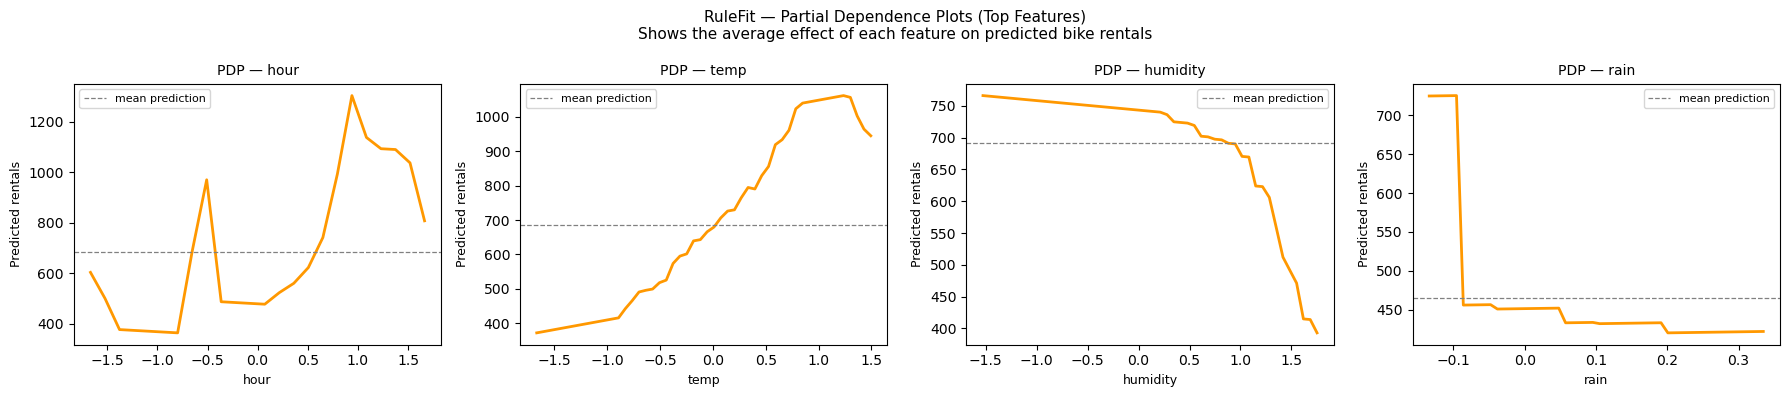

In [827]:
from sklearn.inspection import partial_dependence

TOP_FEATURES = ['hour', 'temp', 'humidity', 'rain']

fig, axes = plt.subplots(1, len(TOP_FEATURES), figsize=(18, 4), sharey=False)

for ax, feat in zip(axes, TOP_FEATURES):
    feat_idx = X_train.columns.tolist().index(feat)
    pd_results = partial_dependence(
        rulefit, X_train, features=[feat_idx],
        kind='average', grid_resolution=50
    )
    grid_vals = pd_results['grid_values'][0]
    avg_pred  = pd_results['average'][0]

    ax.plot(grid_vals, avg_pred, color='#FF9800', linewidth=2)
    ax.axhline(avg_pred.mean(), color='grey', linestyle='--', linewidth=0.9, label='mean prediction')
    ax.set_title(f'PDP — {feat}', fontsize=10)
    ax.set_xlabel(feat, fontsize=9)
    ax.set_ylabel('Predicted rentals', fontsize=9)
    ax.legend(fontsize=8)

fig.suptitle(
    'RuleFit — Partial Dependence Plots (Top Features)\n'
    'Shows the average effect of each feature on predicted bike rentals',
    fontsize=11
)
plt.tight_layout()
plt.show()

### Explainable Boosting Machine (EBM)
An EBM is a glass-box generalized additive model (GAM) that learns smooth, non-linear shape functions for each feature via cyclic gradient boosting. Unlike black-box ensembles, every prediction decomposes additively into per-feature contributions plus a small number of learned pairwise interaction terms, making the model fully interpretable by design.

1. We have tuned the following parameters via cross-validation (StratifiedKFold, 4 folds):
- `max_bins` in {128, 256}
- `interactions` in {5, 10, 15}
- `learning_rate` in {0.01, 0.03, 0.05}
  - Due to the heavy computational budget, we limited the grid to these three hyperparameters. The grid explores the trade-off between feature resolution (`max_bins`) , model complexity (`interactions`) and convergence speed (`learning_rate` ). Other parameters were left at their defaults, though expanding the grid, with the current parameters and to include other parameters, we could've potentially improve performance.

In [ ]:
from interpret.glassbox import ExplainableBoostingRegressor
from sklearn.model_selection import GridSearchCV


ebm = ExplainableBoostingRegressor(random_state=42)
param_grid_ebm = {
    'max_bins': [128, 256],                   
    'interactions': [5, 10, 15],              
    'learning_rate': [0.01, 0.03, 0.05],     
}
grid_search_ebm = GridSearchCV(ebm, param_grid_ebm, cv=stratified_kfold.split(X_train, training_cluster_numbers), 
                               scoring='neg_mean_squared_error', return_train_score=True, n_jobs=-1)
grid_search_ebm.fit(X_train, y_train)

print("Best parameters:", grid_search_ebm.best_params_)
print("Best RMSE:", np.sqrt(-grid_search_ebm.best_score_).round(2))

**Cross-validation output**:
- Best parameters: {'interactions': 15, 'learning_rate': 0.01, 'max_bins': 256} .
- Best RMSE: 239.67

*Note: the CV RMSE above is the in-sample cross-validated score. The true test-set performance is reported below.*

In [757]:
ebm = ExplainableBoostingRegressor(max_bins=256, max_interaction_bins=32, learning_rate=0.01, interactions=15,  random_state=42)
ebm.fit(X_train, y_train)

,feature_names,None
,feature_types,None
,max_bins,256
,max_interaction_bins,32
,interactions,15
,exclude,None
,validation_size,0.15
,outer_bags,14
,inner_bags,0
,learning_rate,0.01
,greedy_ratio,10.0


In [759]:
ebm_predict = ebm.predict(X_test)
ebm_rmse = np.sqrt(mean_squared_error(y_test, ebm_predict))
ebm_mae = mean_absolute_error(y_test, ebm_predict)
ebm_r2 = r2_score(y_test, ebm_predict)

fits.loc["EBM"] = [ebm_rmse, ebm_mae, ebm_r2]
fits.style.background_gradient(cmap='viridis')

,RMSE,MAE,R2
Random Forest,181.680000,104.110993,0.920780
XGBoost,154.220000,86.407143,0.942913
RuleFit,224.127528,151.649569,0.879435
EBM,242.605001,166.110881,0.858736


#### EBM Performance Summary

The EBM achieves an R² of 0.86, placing it below the XGBoost (0.94), Random Forest (0.92), and RuleFit (0.88). Several factors explain this:

1. **Additive structure**: Even with pairwise interactions, the EBM cannot capture higher-order interactions (for example: hour × temp × workingday) that tree ensembles handle naturally.
2. **Cyclic boosting convergence**: With `learning_rate=0.01`, the model learns conservatively.

Despite this gap, the EBM provides shape functions and interaction contour plots that offer richer interpretability than the Random Forest or XGBoost.

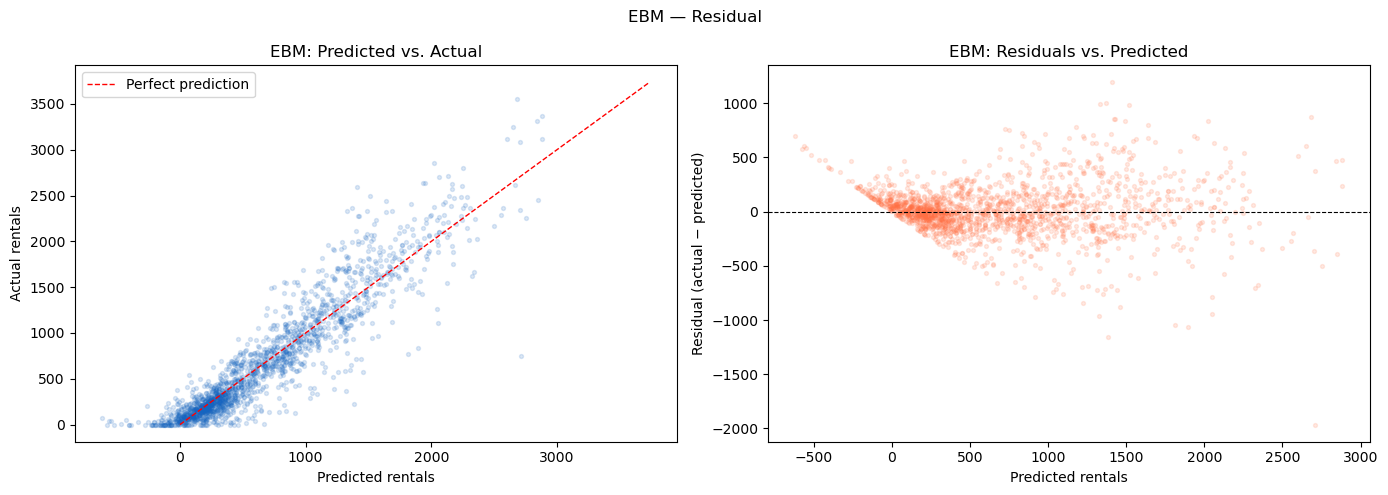

In [830]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

residuals = y_test.values - ebm_predict

# Predicted vs Actual
ax = axes[0]
ax.scatter(ebm_predict, y_test, alpha=0.15, s=8, color='#1565C0')
lims = [0, max(y_test.max(), ebm_predict.max()) * 1.05]
ax.plot(lims, lims, 'r--', linewidth=1, label='Perfect prediction')
ax.set_xlabel('Predicted rentals')
ax.set_ylabel('Actual rentals')
ax.set_title('EBM: Predicted vs. Actual')
ax.legend()

# Residuals vs Predicted
ax = axes[1]
ax.scatter(ebm_predict, residuals, alpha=0.15, s=8, color='#FF7043')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Predicted rentals')
ax.set_ylabel('Residual (actual − predicted)')
ax.set_title('EBM: Residuals vs. Predicted')

plt.suptitle('EBM — Residual', fontsize=12)
plt.tight_layout()
plt.show()


**Predicted vs. Actual (left panel):**
1. **Low-demand** (0–500 rentals): The model tracks the diagonal well, with a tight cluster around the line.
2. **Mid demand** (500–2000 rentals): The scatter starts to widen in both directions and a slight upward drift becomes visible toward 2000, suggesting the model begins to underpredict as demand grows. 
3. **Extreme demand** (>2500 rentals): A handful of observations are substantially underpredicted, as the EBM's additive structure cannot fully represent the compounding effect of ideal conditions.

**Residuals vs. Predicted (right panel):**
1. Residual variance grows with predicted demand. This mirrors the same pattern observed in RuleFit, suggesting it is a structural limitation of additive models on this dataset.
2. At predicted values above ~1500, residuals skew noticeably positive (actual > predicted), confirming that the EBM struggles most with peak-demand conditions.

#### Feature importance findings

- **Temperature** (importance ≈ 283) and **Hour** (≈ 270) are by far the two most important features, each contributing on average 270–280 rentals to predictions. This confirms the same top2 ranking found by the RuleFit model.
- **Solar radiation** (≈ 205) ranks third and is notably more important than the remaining features, underscoring that sunlight is a key driver of cycling demand beyond what temperature alone captures.
- **Dew point** (≈ 128) ranks fourth, acting as a proxy for perceived discomfort.
- The top interaction term, **hour × temp** (≈ 119), ranks 5th. This is higher than standalone humidity (≈ 70). This indicates that the interaction between time-of-day and temperature is more predictive than humidity alone.
- Two more hour-based interactions appear in the top: **hour × dew point** (≈ 69) and **hour × humidity** (≈ 48).
- **Rain** (≈ 37) ranks surprisingly low as a standalone feature, likely because its effect is already partially captured by humidity and dew point.
  
- Seasonal and calendar features (season_Autumn, season_Winter, workingday_Yes/No) cluster at the bottom with importances around 30–33, acting as minor baseline adjustments rather than primary demand drivers.

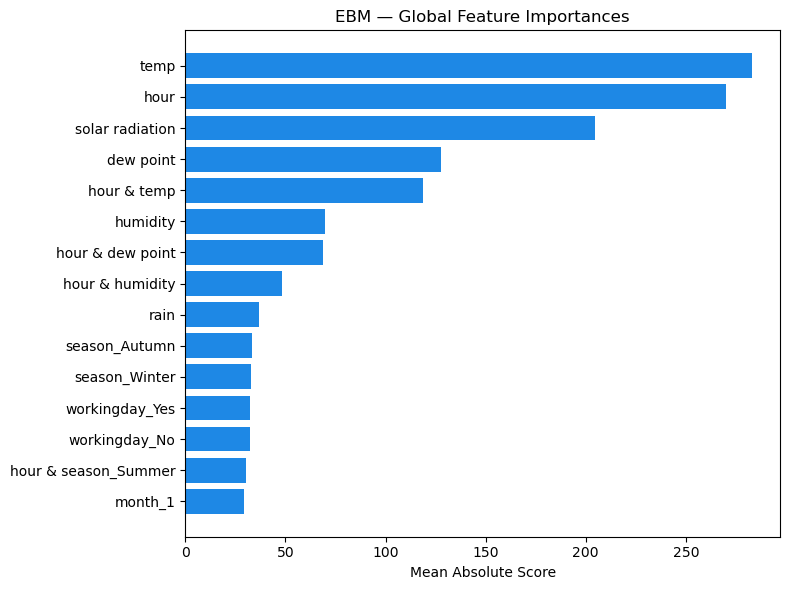

Top 15 terms:
             feature  importance
                temp  282.897865
                hour  269.846482
     solar radiation  204.751030
           dew point  127.816595
         hour & temp  118.911190
            humidity   69.772933
    hour & dew point   68.592655
     hour & humidity   48.403475
                rain   36.880815
       season_Autumn   33.326403
       season_Winter   32.694748
      workingday_Yes   32.486607
       workingday_No   32.475455
hour & season_Summer   30.476568
             month_1   29.242350


In [858]:
ebm_importances = pd.DataFrame({
    'feature':    ebm_best.term_names_,
    'importance': ebm_best.term_importances()
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(ebm_importances['feature'].head(15), ebm_importances['importance'].head(15), color='#1E88E5')
ax.invert_yaxis()
ax.set_title('EBM — Global Feature Importances')
ax.set_xlabel('Mean Absolute Score')
plt.tight_layout()
plt.show()

print('Top 15 terms:')
print(ebm_importances.head(15).to_string(index=False))

#### Shape function findings

- **Hour:**
- Bimodal pattern.
  - Nighttime hours (~ 0–5h) suppress demand by up to −400 rentals.
  - Morning commute peak appears near ~ 8h (contribution ≈ +200 rentals), followed by a midday dip. Then the dominant evening peak at (~ 18–20h) reaching up to +575 rentals.
    
- **Temperature:**
- A smooth S-shaped curve.
  - Very cold temperatures (roughly below −10°C) suppress demand by up to −400 rentals.
  - The contribution rises steeply through the 0–15°C range, plateaus around temp ~ 25°C at about +500 rentals, and shows a slight decline at the very highest temperatures.

    
- **Solar Radiation:**
- Positive and approximately concave.
  - The contribution jumps sharply from −200 rentals at zero radiation to about +300 rentals as solar radiation increases, then plateaus.
  - The confidence interval widens substantially at the highest values, indicating sparse data in extreme values.


- **Dew Point:**
- Predominantly negative.
  - Very low dew points (cold dry winter conditions) suppress demand severely (down to −500 rentals), with a wide confidence band reflecting data sparsity in extreme cold.
  - Overall the graph shows that extreme dew points in either direction hurt demand.

  
- **Humidity:**
- Declining curve with a left-tail spike.
  - Very low standardised humidity (very dry air) shows a sharp positive spike (+275 rentals), but this region has a wide CI and likely few observations.
  - Rising humidity steadily suppresses demand, reaching about −400 rentals at the highest values.
  - High humidity is one of the clearest single-feature suppressors of cycling demand.




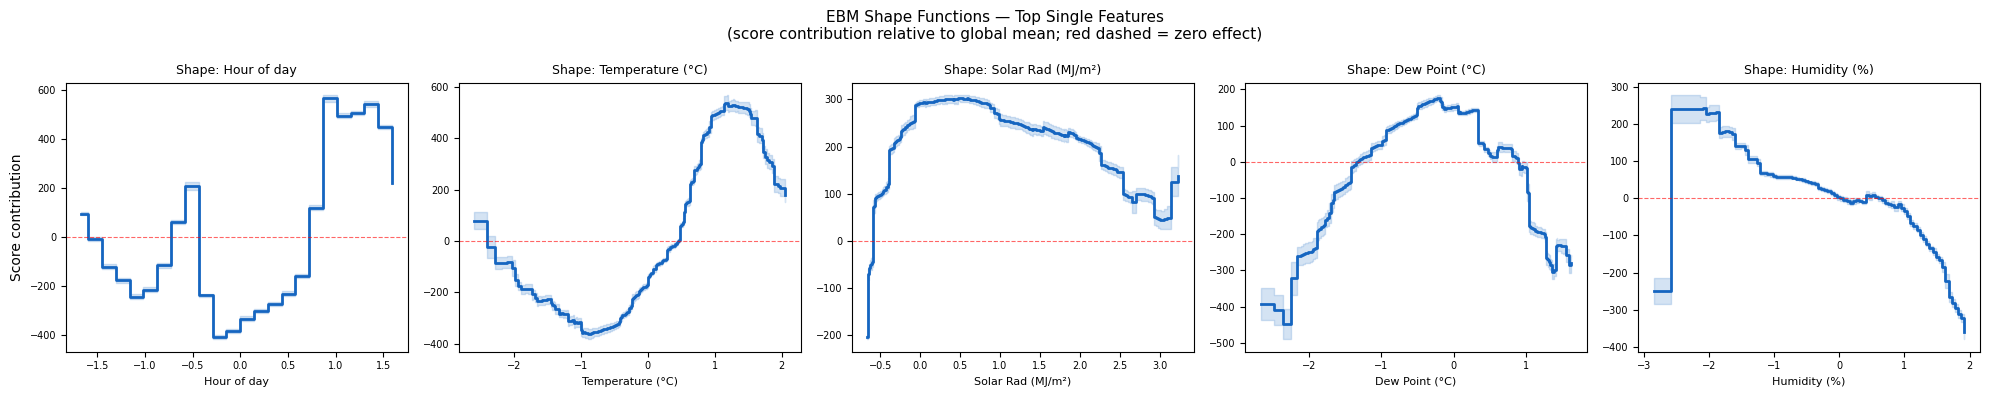

In [773]:
ebm_global_viz = ebm.explain_global(name='EBM')

top_features = ['hour', 'temp', 'solar radiation', 'dew point', 'humidity']
labels       = ['Hour of day', 'Temperature (°C)', 'Solar Rad (MJ/m²)', 'Dew Point (°C)', 'Humidity (%)']

fig, axes = plt.subplots(1, len(top_features), figsize=(20, 4))

for ax, feat, label in zip(axes, top_features, labels):
    idx   = ebm.term_names_.index(feat)
    data  = ebm_global_viz.data(idx)
    bins  = data['names'][:-1]        
    scores = data['scores']

    ax.step(bins, scores, where='post', color='#1565C0', linewidth=2)
    ax.fill_between(bins, data['lower_bounds'], data['upper_bounds'],
                    alpha=0.18, step='post', color='#1565C0')
    ax.axhline(0, color='red', linewidth=0.8, linestyle='--', alpha=0.6)
    ax.set_xlabel(label, fontsize=8)
    ax.set_title(f'Shape: {label}', fontsize=9)
    ax.tick_params(labelsize=7)

axes[0].set_ylabel('Score contribution')
plt.suptitle(
    'EBM Shape Functions — Top Single Features\n'
    '(score contribution relative to global mean; red dashed = zero effect)', fontsize=11)
plt.tight_layout()
plt.show()

#### Interaction Terms

The EBM automatically detects pairwise interactions. The contour plots below show the joint effect of the top 3 interaction terms. These are additive corrections on top of the individual shape functions.

**Interaction contour findings** :

- **Hour × Temp** (left panel):
  - The deep red region (score > +200) indicate that warm temperatures during rush hours (morning and evening) produce a synenergistic demand boost. People are more likely to cycle to work when it is warm outside.
  - Colder temperatures suppress demand more than either factor alone would predict, confirming that even when the time of day should support some cycling, cold weather kills demand disproportional.


- **Hour × Dew Point** (middle panel):
  - A mostly negative interaction (scores down to −160).
  - Indicates that the combined effect of hour and dew point on bike demand is generally weaker than the individual shape functions would suggest.
  - The positive band (up to +320) at high dew points during early-morning hours likely reflects summer mornings. These are conditions that coincide with warm weather and long daylight, where bike riders tolerate higher dew points because the overall conditions are still favorable for cycling.


  
- **Hour × Humidity** (right panel):
  - Low humidity during evening peak hours shows a strong negative interaction (down to −500), while high humidity during the same hours shows a positive one (+200).
  - This is a correction term: since the individual humidity shape function already heavily penalises high humidity, the interaction partially offsets that penalty during evening rush hours.


- All three top interactions involve **hour** as one of the pair, reinforcing that time-of-day modulates the effect of weather variables rather than weather variables interacting with each other independently.

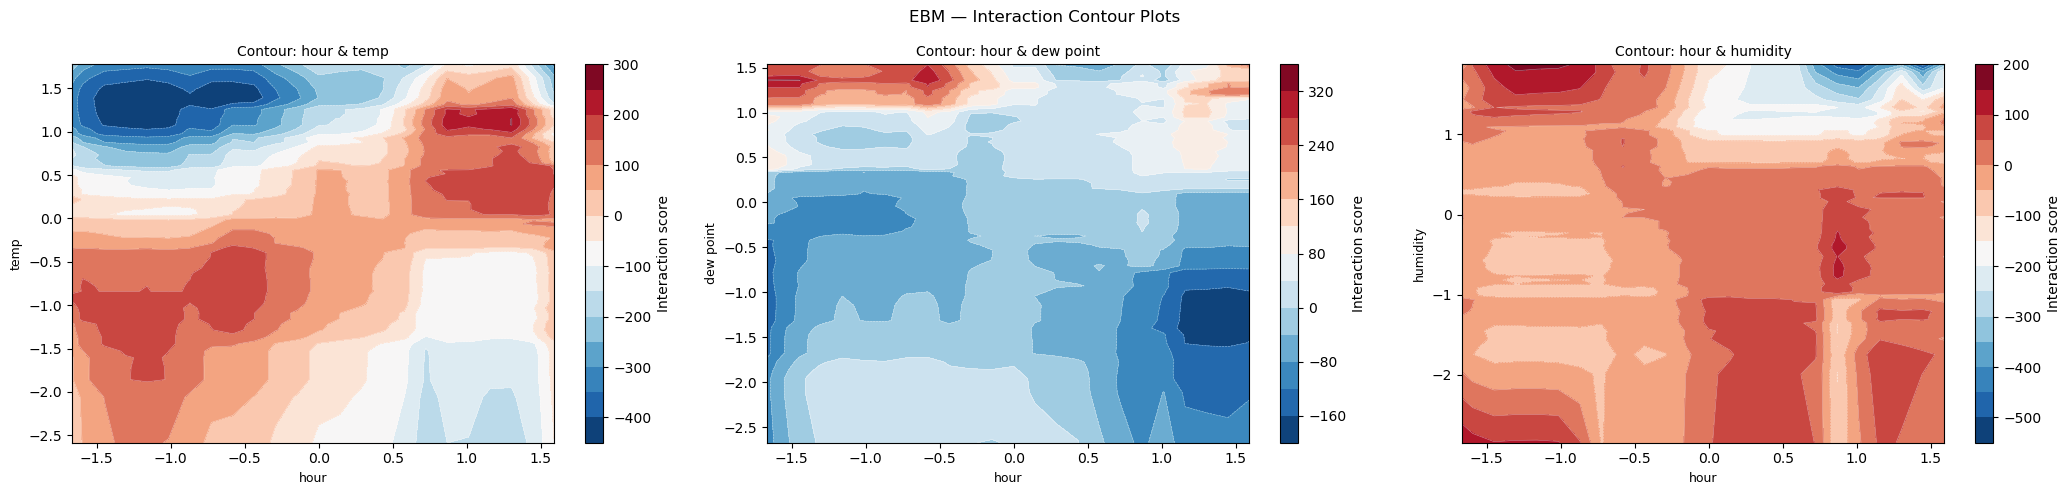

In [850]:
ebm_global_int  = ebm_best.explain_global(name='EBM')
importances_all = ebm_best.term_importances()

# Collect top 3 interaction terms by importance
interaction_terms = [(i, name) for i, name in enumerate(ebm_best.term_names_) if ' & ' in name]
interaction_terms = sorted(interaction_terms, key=lambda t: importances_all[t[0]], reverse=True)[:3]

fig, axes = plt.subplots(1, len(interaction_terms), figsize=(7 * len(interaction_terms), 5))
if len(interaction_terms) == 1:
    axes = [axes]

for ax, (idx, name) in zip(axes, interaction_terms):
    d = ebm_global_int.data(idx)
    scores   = np.array(d['scores'])      
    x_edges  = d['left_names']            
    y_edges  = d['right_names']           

    if scores.ndim != 2:
        ax.set_visible(False)
        continue

    x_vals   = np.array(x_edges[:-1], dtype=float)
    y_vals   = np.array(y_edges[:-1], dtype=float)
    feat_a, feat_b = name.split(' & ')

    X_grid, Y_grid = np.meshgrid(x_vals, y_vals)
    cf = ax.contourf(X_grid, Y_grid, scores.T, levels=15, cmap='RdBu_r')
    ax.contour(X_grid, Y_grid, scores.T, levels=15,
               colors='white', linewidths=0.4, alpha=0.5)
    plt.colorbar(cf, ax=ax, label='Interaction score')
    ax.set_xlabel(feat_a, fontsize=9)
    ax.set_ylabel(feat_b, fontsize=9)
    ax.set_title(f'Contour: {name}', fontsize=10)

fig.suptitle(
    'EBM — Interaction Contour Plots',
    fontsize=12
)
plt.tight_layout()
plt.show()

**Heatmap findings**

- The EBM captures the dominant seasonal-hourly demand structure well. Both panels show same broad pattern of really low nighttime demand and peaks in morning and evening demands in the spring, summer, and autumn.
- Differences between both are visible in the mean rentals during the morning peak of 8h. This is likely due to the sharp spike in bike rentals. The EBM's shape function (for hour) captures this spike as a step-function with discrete bins. So it can't completely replicate the single-hour spike. Therefore it smooths this across neighbouring bins.




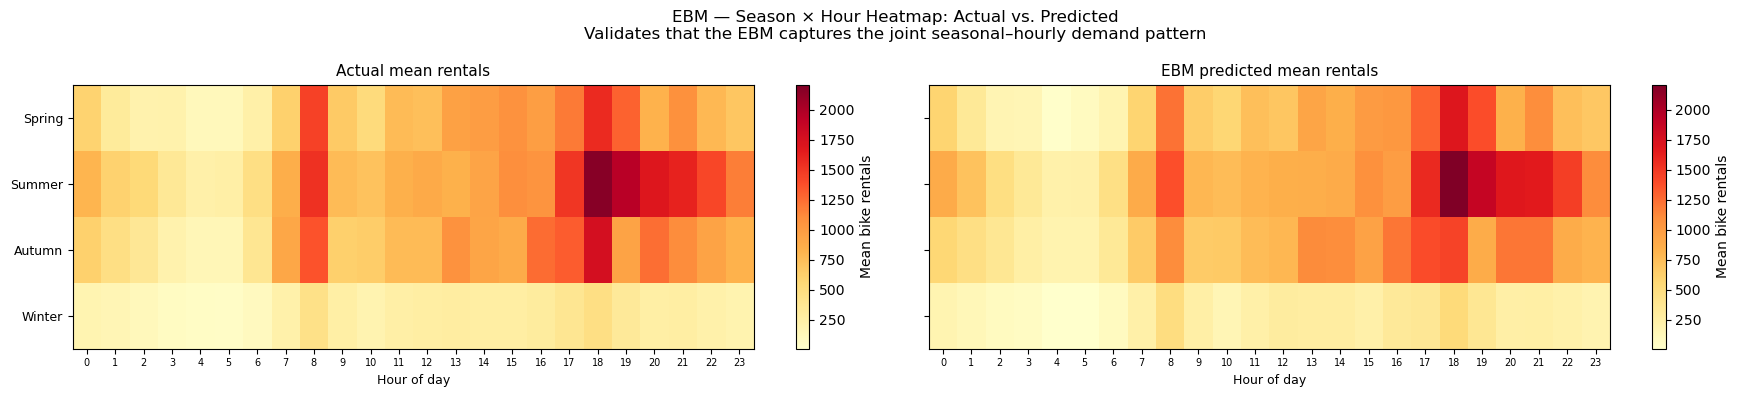

In [443]:
seasons_order = ['Spring', 'Summer', 'Autumn', 'Winter']

df_hmap = test_data[['season', 'hour']].copy().reset_index(drop=True)
df_hmap['actual']    = y_test.values
df_hmap['predicted'] = ebm.predict(X_test)

pivot_actual = (df_hmap.groupby(['season', 'hour'])['actual']
                        .mean().unstack('hour').reindex(seasons_order))
pivot_pred   = (df_hmap.groupby(['season', 'hour'])['predicted']
                        .mean().unstack('hour').reindex(seasons_order))

vmin = min(pivot_actual.min().min(), pivot_pred.min().min())
vmax = max(pivot_actual.max().max(), pivot_pred.max().max())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 4), sharey=True)

for ax, pivot, title in [
    (ax1, pivot_actual, 'Actual mean rentals'),
    (ax2, pivot_pred,   'EBM predicted mean rentals')
]:
    im = ax.imshow(pivot.values, aspect='auto', cmap='YlOrRd',
                   vmin=vmin, vmax=vmax)
    ax.set_xticks(range(24))
    ax.set_xticklabels(range(24), fontsize=7)
    ax.set_yticks(range(len(seasons_order)))
    ax.set_yticklabels(seasons_order, fontsize=9)
    ax.set_xlabel('Hour of day', fontsize=9)
    ax.set_title(title, fontsize=11)
    plt.colorbar(im, ax=ax, label='Mean bike rentals')

fig.suptitle(
    'EBM — Season × Hour Heatmap: Actual vs. Predicted\n'
    'Validates that the EBM captures the joint seasonal–hourly demand pattern',
    fontsize=12
)
plt.tight_layout()
plt.show()

#### InterpretML interactive dashboard
1. In this dashboard, we can toggle between several views. This is what it all shows:

- Summary view : a bar chart with global feature importance.
- Shape function plots (per feature): it shows the learned step-function, including a confidence interval. This equals the shape functions we have shown earlier.
- Interaction plots: for each pairwise interaction (15 in our case), it shows a heatmap of joint score contribution.

In [854]:
from interpret import show

ebm_global = ebm_best.explain_global()
show(ebm_global)

<!-- http://127.0.0.1:7001/6287541648/ -->

### Comparing EBM and RuleFit

**Performance comparison**
- RuleFit slightly outperforms EBM, but both fall below the baseline of R²
  - This gap can be explained as the expected cost of enforcing interpretability.
  - RuleFit's Lasso-penalty and EBM's additive structure both limit capacity of higher-order interactions
  - For our case, this trade-off can be acceptable, since understanding bike rental demand drivers probably matters more than accuracy gains.

**Interpretability**
- RuleFit produces discrete, readable rules. These can be useful for threshold-based decisions.
- Whereas EBM produces smooth shape functions which show continous relationships, these can be preferred for looking at gradual effects.
- To some degree these complement each other. RuleFit highlights critical thresholds, EBM reveals what happens in between these thresholds.

**Recommendation**
- EBM is a stronger glass-box method if goal is to look at smooth effects.
- RuleFit is preferable when decision rules are necessary for operations.

In [802]:
fits.style.background_gradient(cmap='viridis')

,RMSE,MAE,R2
Random Forest,181.680000,104.110993,0.920780
XGBoost,154.220000,86.407143,0.942913
RuleFit,224.127528,151.649569,0.879435
EBM,242.605001,166.110881,0.858736


## Comparison of models

Blackbox model XGBoost has the best permformance with highest R^2 (0.94), lowest RMSE (154.22), lowest MAE (86.41)

Random Forest comes closest to XGBoost with an R^2 of 0.92, an RMSE of 181.6 and an MAE of 104.11.

EBM had an R^2 of 0.86, RMSE of 244.96 and MAE of 167.21. Making it a balanced, reliable and interpretable model.

Rule fit has a slightly lower R^2 of 0.82 and higher RMSE (275.89) and MAE (190.26) than EBM.

Linear regression performed signficantly worse than these models with an R^2 of 0.58, RMSE of 419.60 and MAE of 316.32. Linear regression does not capture the patterns well in this data.

Similarly SVR performs poorly too with an R^2 of 0.55, RMSE of 433.33 and MAE of 305.47. Suggesting that it is not suited for this task either.

We conclude that XGBoost is the best model for performance. EBM and rule fit are preferres when interpretability is important. Both linear regression and SVR are not recommended. These results are in line with the accuracy interpretability trade off that we have seen in the lecture.